In [1]:
# Lab 7 Learning rate and Evaluation
import torch
import torchvision.datasets as dsets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import random

In [2]:
device = 'cpu'

# for reproducibility
random.seed(777)
torch.manual_seed(777)
if device == 'cuda':
    torch.cuda.manual_seed_all(777)

In [3]:
# parameters
training_epochs = 15
batch_size = 100

In [7]:
# MNIST dataset
mnist_train = dsets.MNIST(root='E:\pwr\leaning\Start-with-Pytorch\data',
                          train=True,
                          transform=transforms.ToTensor(),
                          download=True)

mnist_test = dsets.MNIST(root='E:\pwr\leaning\Start-with-Pytorch\data',
                         train=False,
                         transform=transforms.ToTensor(),
                         download=True)

Using downloaded and verified file: E:\pwr\leaning\Start-with-Pytorch\data\MNIST\raw\train-images-idx3-ubyte.gz
Extracting E:\pwr\leaning\Start-with-Pytorch\data\MNIST\raw\train-images-idx3-ubyte.gz to E:\pwr\leaning\Start-with-Pytorch\data\MNIST\raw

Using downloaded and verified file: E:\pwr\leaning\Start-with-Pytorch\data\MNIST\raw\train-labels-idx1-ubyte.gz
Extracting E:\pwr\leaning\Start-with-Pytorch\data\MNIST\raw\train-labels-idx1-ubyte.gz to E:\pwr\leaning\Start-with-Pytorch\data\MNIST\raw

Using downloaded and verified file: E:\pwr\leaning\Start-with-Pytorch\data\MNIST\raw\t10k-images-idx3-ubyte.gz
Extracting E:\pwr\leaning\Start-with-Pytorch\data\MNIST\raw\t10k-images-idx3-ubyte.gz to E:\pwr\leaning\Start-with-Pytorch\data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found

Failed download. Trying https -> http instead. Downloading http://ossci-datasets.s3.amazonaws.com/mnist/t10k-labels-idx1-ubyte.gz to E:\pwr\leaning\Start-with-Pytorch\data\MNIST\raw\t10

100.0%

Extracting E:\pwr\leaning\Start-with-Pytorch\data\MNIST\raw\t10k-labels-idx1-ubyte.gz to E:\pwr\leaning\Start-with-Pytorch\data\MNIST\raw



In [8]:
# dataset loader
data_loader = torch.utils.data.DataLoader(dataset=mnist_train,
                                          batch_size=batch_size,
                                          shuffle=True,
                                          drop_last=True)

In [9]:
# MNIST data image of shape 28 * 28 = 784
linear = torch.nn.Linear(784, 10, bias=True).to(device)

In [10]:
# define cost/loss & optimizer
criterion = torch.nn.CrossEntropyLoss().to(device)    # Softmax is internally computed.
optimizer = torch.optim.SGD(linear.parameters(), lr=0.1)

In [11]:
for epoch in range(training_epochs):
    avg_cost = 0
    total_batch = len(data_loader)

    for X, Y in data_loader:
        # reshape input image into [batch_size by 784]
        # label is not one-hot encoded
        X = X.view(-1, 28 * 28).to(device)
        Y = Y.to(device)

        optimizer.zero_grad()
        hypothesis = linear(X)
        cost = criterion(hypothesis, Y)
        cost.backward()
        optimizer.step()

        avg_cost += cost / total_batch

    print('Epoch:', '%04d' % (epoch + 1), 'cost =', '{:.9f}'.format(avg_cost))

print('Learning finished')

Epoch: 0001 cost = 0.535150588
Epoch: 0002 cost = 0.359577745
Epoch: 0003 cost = 0.331264257
Epoch: 0004 cost = 0.316404670
Epoch: 0005 cost = 0.307107002
Epoch: 0006 cost = 0.300456554
Epoch: 0007 cost = 0.294933379
Epoch: 0008 cost = 0.290956199
Epoch: 0009 cost = 0.287074059
Epoch: 0010 cost = 0.284515619
Epoch: 0011 cost = 0.281914055
Epoch: 0012 cost = 0.279526860
Epoch: 0013 cost = 0.277636588
Epoch: 0014 cost = 0.275874794
Epoch: 0015 cost = 0.274422735
Learning finished


Accuracy: 0.8883000016212463
Label:  8
Prediction:  3


e:\Users\Admin\anaconda3\envs\new_pytorch\lib\site-packages\torchvision\datasets\mnist.py:81: UserWarning: test_data has been renamed data
  warnings.warn("test_data has been renamed data")
e:\Users\Admin\anaconda3\envs\new_pytorch\lib\site-packages\torchvision\datasets\mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")


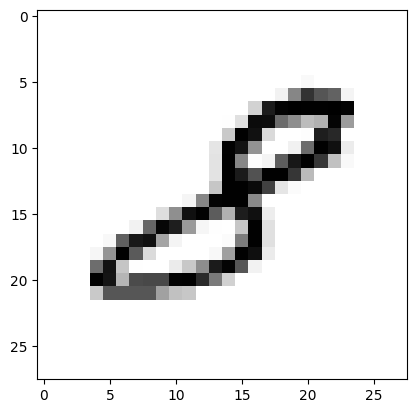

In [12]:
# Test the model using test sets
with torch.no_grad():
    X_test = mnist_test.test_data.view(-1, 28 * 28).float().to(device)
    Y_test = mnist_test.test_labels.to(device)

    prediction = linear(X_test)
    correct_prediction = torch.argmax(prediction, 1) == Y_test
    accuracy = correct_prediction.float().mean()
    print('Accuracy:', accuracy.item())

    # Get one and predict
    r = random.randint(0, len(mnist_test) - 1)
    X_single_data = mnist_test.test_data[r:r + 1].view(-1, 28 * 28).float().to(device)
    Y_single_data = mnist_test.test_labels[r:r + 1].to(device)

    print('Label: ', Y_single_data.item())
    single_prediction = linear(X_single_data)
    print('Prediction: ', torch.argmax(single_prediction, 1).item())

    plt.imshow(mnist_test.test_data[r:r + 1].view(28, 28), cmap='Greys', interpolation='nearest')
    plt.show()